# Agglomerative Clustering (Hierarchical Clustering)

Agglomerative clustering is a **bottom-up hierarchical clustering algorithm**.

Algorithm idea:

- Start each data point as its own cluster
- Iteratively merge the two most similar clusters
- Continue merging until a *stopping criterion* is satisfied 

Typical stoppping criteria:
- A fixed **number of clusters**
- A **distance threshold**

# linkage Criteria
To decide **which clusters should be merged**, the algorithm needs a definetion of cluster similarity. This is called the **linkage criterion**.

Common linkage methods:

- **ward linkage (default)**
Minimize the increase in **within-cluster variance** after merging clusters.
This tends to produce compact, spherical clusters and behaves similarly to **k-means**.

- **Average linkage**
Uses the **average pairwise distance** between all points in the two clusters.

- **Complete linkage**
Uses the **maximum distance** between points of the two clusters. 

Summary:

| Linkage | Cluster distance definition |
|-------|-----------------------------|
| Ward | Increase in within-cluster variance |
| Average | Mean pairwise distance |
| Complete | Maximum pairwise distance |
 

In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import  AgglomerativeClustering
from sklearn.datasets import make_blobs, make_moons
from sklearn.preprocessing import StandardScaler

from scipy.cluster.hierarchy import dendrogram, ward

# First example: basic agglomerative clustering
## Example 1: Agglomerative Clustering on Synthetic Data

We generate synthetic data using `make_blobs` and apply agglomerative clustering.

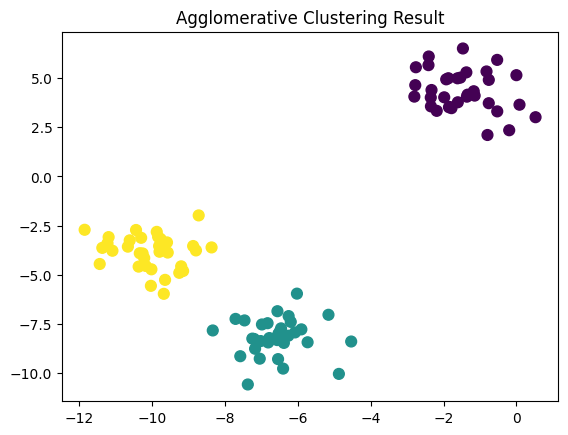

In [39]:
X, y = make_blobs(random_state=1)

agg = AgglomerativeClustering(n_clusters=3)
assignment = agg.fit_predict(X)

plt.scatter(X[:, 0], X[:, 1], c=assignment, s=60)
plt.title("Agglomerative Clustering Result")
plt.show()

The algorithm groups points based on distance and the chosen linkage criterion.
Here we directly specify the number of clusters (`n_clusters=3`).

# Hierarchical Clustering and Dendrograms

A key advantage of hierarchical clustering is that it produces a **full hierarchy of cluster merges**.

Each every point makes a journey from being a single cluster to belonging to some final cluster.

This entire merging process can be visualized using a **dendrogram** (tree diagram).

A dendrogram shows:

- when clusters merge
- the distance at which they merge
- the hierarchical structure of the clustering process

## Example: Visualizing the clustering process with a dendrogram

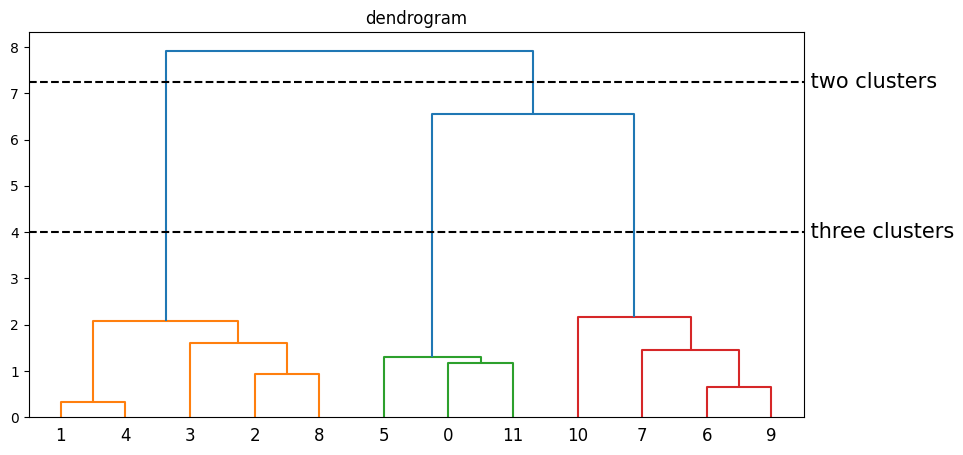

In [40]:
X, y = make_blobs(random_state=0, n_samples=12)

linkage_array = ward(X)

plt.figure(figsize=(10, 5))
dendrogram(linkage_array)

ax = plt.gca()
bounds = ax.get_xbound()

ax.plot(bounds, [7.25, 7.25], '--', c='k')
ax.plot(bounds, [4, 4], '--', c='k')

ax.text(bounds[1], 7.25, ' two clusters', verticalalignment='center', fontdict={'size': 15})
ax.text(bounds[1], 4, ' three clusters', verticalalignment='center', fontdict={'size': 15})

plt.title("dendrogram")
plt.show()

The horizontal lines illustrate **cutting the dendrogram** at different heights.

Cutting the tree determines the number of clusters:

- A higher cut -> fewer clusters
- A lower cut -> more clusters

## Linkage matrix

The function `ward(X)` returns a **linkage matrix**

Each row describes one merge operation:
[cluster_1, cluster_2, distance, sample_count]


Meaning:

| Column | Meaning |
|------|--------|
| 1 | first merged cluster |
| 2 | second merged cluster |
| 3 | distance between clusters |
| 4 | number of samples in the resulting cluster |

If there are **n samples**, the linkage matrix has **n−1 rows** because we need n−1 merges to combine everything into a single cluster.




In [41]:
linkage_array

array([[ 1.        ,  4.        ,  0.3320945 ,  2.        ],
       [ 6.        ,  9.        ,  0.64580193,  2.        ],
       [ 2.        ,  8.        ,  0.92683223,  2.        ],
       [ 0.        , 11.        ,  1.1803787 ,  2.        ],
       [ 5.        , 15.        ,  1.30311575,  3.        ],
       [ 7.        , 13.        ,  1.4440339 ,  3.        ],
       [ 3.        , 14.        ,  1.60041812,  3.        ],
       [12.        , 18.        ,  2.07815795,  5.        ],
       [10.        , 17.        ,  2.15981886,  4.        ],
       [16.        , 20.        ,  6.55024854,  7.        ],
       [19.        , 21.        ,  7.92446877, 12.        ]])

## Example: two-moons dataset

The two-moons dataset is commonly used to test clustering algorithms.

It contains **two non-convex clusters**, which are difficult for algorithms that assume spherical clusters.

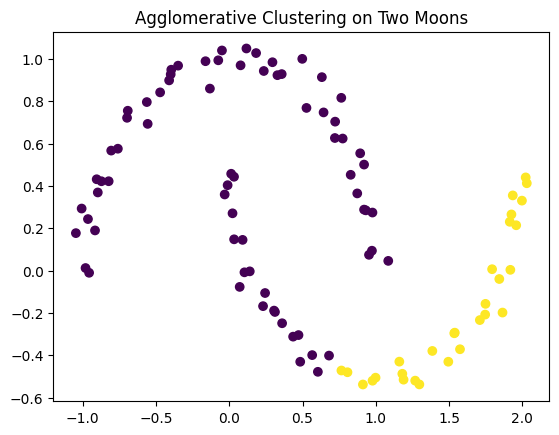

In [42]:
X, y = make_moons(n_samples=100, noise=0.05, random_state=0)


agc = AgglomerativeClustering(n_clusters=2)
labels = agc.fit_predict(X)

plt.scatter(X[:, 0], X[:, 1], c=labels)
plt.title("Agglomerative Clustering on Two Moons")
plt.show()

## Visualizing the hierarchy by changing the number of clusters

A dendrogram shows the full merge history, but sometimes it is easier to understand hierarchical clustering by directly plotting the clustering result for different values of `n_clusters`.

This helps connect:

- the **tree structure** in the dendrogram
- the **actual partition** of the data
- the idea that hierarchical clustering produces a **nested sequence of clusterings**

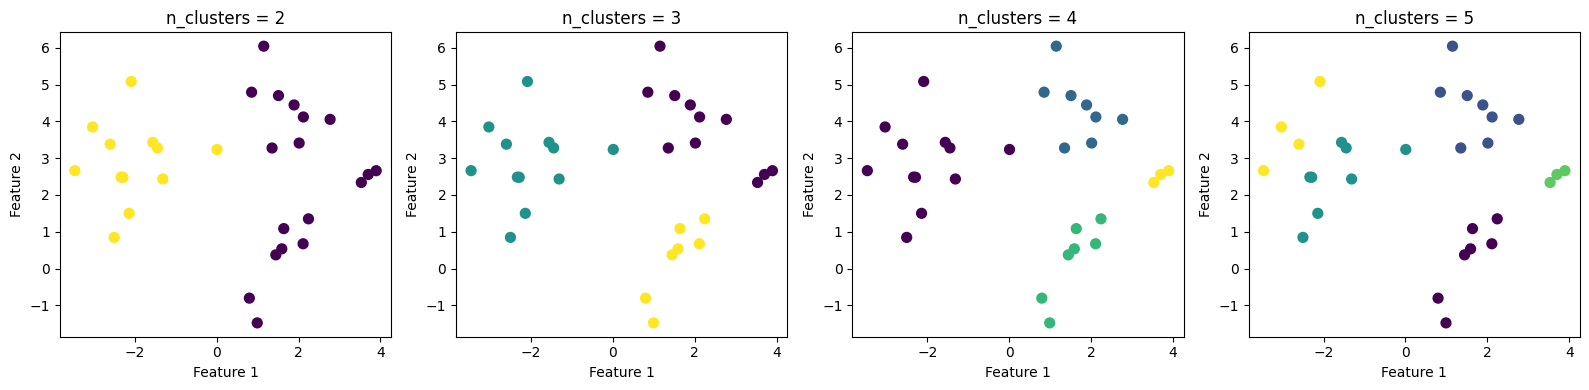

In [43]:
X, y = make_blobs(random_state=0, n_samples=30, centers=3, cluster_std=1.2)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for ax, n_clusters in zip(axes, [2, 3, 4, 5]):
    model = AgglomerativeClustering(n_clusters=n_clusters)
    labels = model.fit_predict(X)
    
    ax.scatter(X[:, 0], X[:, 1],c=labels, s=50)
    ax.set_title(f"n_clusters = {n_clusters}")
    ax.set_xlabel("Feature 1")
    ax.set_ylabel("Feature 2")

plt.tight_layout()
plt.show()    

This plot shows that hierarchical clustering does not create unrelated clusterings for different values of `n_clusters`.

Instead, it creates a **nested hierarchy**:

- when we move from fewer clusters to more clusters,
- existing clusters are split into smaller subclusters,
- consistent with the merge/split structure shown by the dendrogram.

This is a key difference from methods such as k-means, where solutions for different values of `k` are fitted separately.

## Hierarchical clustering vs. k-means

Hierarchical clustering:
- builds a full clustering tree
- allows us to choose the number of clusters afterward
- produces nested cluster structures

k-means:
- requires specifying the number of clusters in advance
- fits one partition for one chosen value of `k`
- does not produce a hierarchy
- hierarchical clustering = one tree, many cuts
- k-means = separate optimization for each $k$

# Key Takeaways

- Agglomerative clustering builds clusters **bottom-up** by merging similar clusters.

- The **linkage criterion** determines how cluster similarity is measured.

- The **dendrogram** visualizes the entire hierarchical merging process.

- Cutting the dendrogram at different heights produces different numbers of clusters.

- Distance-based clustering methods may struggle with **non-convex cluster shapes** such as the two-moons dataset.